1. Persiapan Data (Loading dan Selection) Tahap awal adalah mempersiapkan lingkungan kerja dan data. Pustaka Pandas diimpor untuk memuat data dari file CSV (data_wisata_bogor_lengkap.csv) ke dalam objek DataFrame. Pustaka NumPy dan modul DBSCAN dari Scikit-learn juga diimpor sebagai inti perhitungan. Langkah paling penting di sini adalah pemilihan variabel: kode secara spesifik mengambil kolom latitude dan longitude dari DataFrame dan menyimpannya sebagai array NumPy dengan nama X. Array X inilah yang menjadi input spasial bagi algoritma DBSCAN, memastikan bahwa proses klastering hanya menggunakan informasi geografis.

In [18]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from os import path
path="/content/drive/MyDrive/MachineLearningPraktikum/Praktikum11/data"

In [6]:
df = pd.read_csv(path + "/data_wisata_bogor_lengkap.csv")
df

,nama_tempat_wisata,kategori,preferensi,kecamatan,kabupaten_kota,rating,jumlah_rating,link,latitude,longitude
0,Taman Budaya Sentul City,Budaya,Wisata Budaya & Edukasi,Babakan Madang,Kabupaten Bogor,4.5,22727.0,https://www.google.com/maps/place/Taman+Budaya...,-6.584002,106.882783
1,Leuwi Kunten Sentul Bogor,Umum,Lainnya,Babakan Madang,Kabupaten Bogor,4.3,1785.0,https://www.google.com/maps/place/Leuwi+Kunten...,-6.578766,106.918910
2,ECOART PARK Sentul City,Alam,Wisata Alam,Babakan Madang,Kabupaten Bogor,4.4,11780.0,https://www.google.com/maps/place/ECOART+PARK+...,-6.568722,106.845751
3,Goa Garunggang - Puncak Dua,Alam,Wisata Alam,Babakan Madang,Kabupaten Bogor,4.6,765.0,https://www.google.com/maps/place/Goa+Garungga...,-6.573150,106.936201
4,Sentul Paradise Park,Alam,Wisata Alam,Babakan Madang,Kabupaten Bogor,3.4,901.0,https://www.google.com/maps/place/Sentul+Parad...,-6.614256,106.908554
...,...,...,...,...,...,...,...,...,...,...
2088,Tanah Sareal Campsite,Umum,Lainnya,Bogor Utara,Kota Bogor,4.7,7.0,https://www.google.com/maps/place/Tanah+Sareal...,-6.562800,106.798473
2089,Delta 15 Ciliwung,Umum,Lainnya,Bogor Utara,Kota Bogor,4.8,15.0,https://www.google.com/maps/place/Delta+15+Cil...,-6.550927,106.803954
2090,Delta Biawak,Umum,Lainnya,Bogor Utara,Kota Bogor,4.3,9.0,https://www.google.com/maps/place/Delta+Biawak...,-6.553514,106.805862
2091,Taman Oreo,Alam,Wisata Alam,Tanah Sareal,Kota Bogor,4.8,28.0,https://www.google.com/maps/place/Taman+Oreo/d...,-6.568695,106.802231


In [9]:
# Memilih kolom koordinat untuk clustering
X = df[['latitude', 'longitude']].values

2. Implementasi Algoritma DBSCAN
Pada tahap ini, klastering dilakukan dengan mendefinisikan dan menerapkan Algoritma DBSCAN. Dua parameter kritis ditentukan: Eps (Epsilon) diatur sebesar 0.005 derajat (setara sekitar 550 meter), yang menentukan radius lingkungan bagi setiap titik data; dan Min\_Samples diatur sebesar 5, yang menentukan jumlah minimum titik yang harus berada dalam radius Eps untuk membentuk klaster yang padat. Dengan parameter ini, objek DBSCAN dibuat dan dijalankan (.fit()) pada data koordinat X. Hasil klastering, yaitu label klaster (0, 1, 2, \dots) atau label noise (-1), kemudian ditambahkan kembali ke DataFrame awal sebagai kolom baru bernama Cluster. Kode juga menghitung jumlah total klaster yang ditemukan serta jumlah titik yang terklasifikasi sebagai noise (titik terisolasi).

In [10]:
# --- 2. Implementasi DBSCAN ---
# Parameter dipilih untuk clustering lokal di Bogor:
# eps = 0.005 derajat (sekitar 550 meter)
# min_samples = 5 (minimal 5 titik untuk membentuk klaster)
EPS_VALUE = 0.005
MIN_SAMPLES_VALUE = 5

In [13]:
db = DBSCAN(eps=EPS_VALUE, min_samples=MIN_SAMPLES_VALUE).fit(X)
df['Cluster'] = db.labels_

In [14]:
# Analisis hasil
n_clusters_ = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise_ = list(db.labels_).count(-1)

print(f"Jumlah Klaster Teridentifikasi: {n_clusters_}")
print(f"Jumlah Titik Noise (-1): {n_noise_}")

Jumlah Klaster Teridentifikasi: 75
Jumlah Titik Noise (-1): 1341


3. Visualisasi Hasil (Plotting Lengkap)Visualisasi adalah kunci untuk memahami hasil DBSCAN. Tahap ini menggunakan pustaka Matplotlib untuk membuat scatter plot. Untuk memastikan visualisasi yang jelas, titik-titik yang masuk ke dalam klaster (k \neq -1) dipisahkan dari titik Noise (k = -1). Titik-titik klaster diplot dengan warna berbeda (menggunakan skema warna Spectral) dan marker besar, sementara titik-titik Noise diplot secara terpisah dengan warna abu-abu, ukuran lebih kecil, dan transparansi (alpha) rendah. Ini memungkinkan klaster padat terlihat menonjol. Plot dilengkapi dengan judul informatif (termasuk nilai Eps dan Min\_Samples), label sumbu (Latitude dan Longitude), dan legenda lengkap yang mencantumkan semua klaster dan noise yang teridentifikasi, kemudian disimpan sebagai file gambar.

In [20]:
# --- 3. Visualisasi Hasil Clustering ---

# Memfilter data klaster dan noise untuk visualisasi yang lebih jelas
df_clustered = df[df['Cluster'] != -1]
X_clustered = df_clustered[['latitude', 'longitude']].values
labels_clustered = df_clustered['Cluster'].values

plt.figure(figsize=(12, 10))

unique_labels = sorted(set(labels_clustered))
colors = matplotlib.colormaps.get_cmap('Spectral')

<Figure size 1200x1000 with 0 Axes>

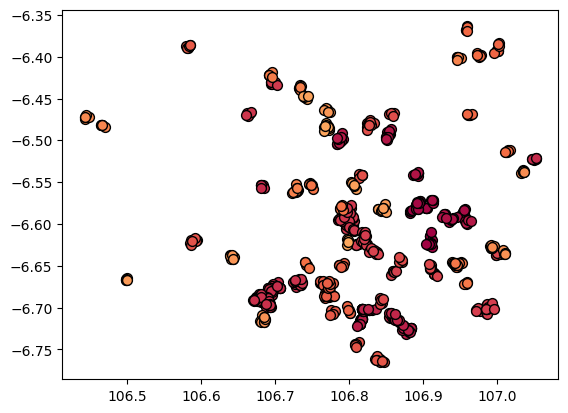

In [21]:
# Plot titik-titik yang menjadi bagian dari klaster
for k in unique_labels:
    class_member_mask = (labels_clustered == k)
    xy = X_clustered[class_member_mask]
    plt.scatter(xy[:, 1], xy[:, 0], s=50, marker='o', color=colors(k), edgecolor='k', label=f'Klaster {k} (n={len(xy)})')

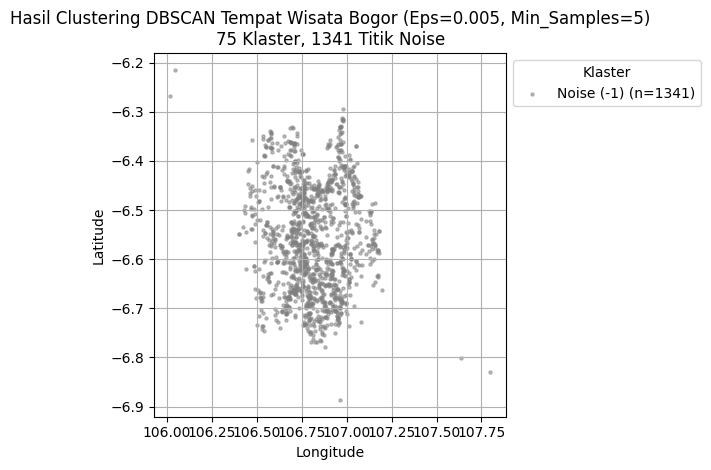

In [23]:
# Plot titik-titik Noise (jika ada)
if n_noise_ > 0:
    df_noise = df[df['Cluster'] == -1]
    xy_noise = df_noise[['latitude', 'longitude']].values
    plt.scatter(xy_noise[:, 1], xy_noise[:, 0], s=20, marker='.', color='gray', label=f'Noise (-1) (n={n_noise_})', alpha=0.5)

plt.title(f'Hasil Clustering DBSCAN Tempat Wisata Bogor (Eps={EPS_VALUE}, Min_Samples={MIN_SAMPLES_VALUE})\n{n_clusters_} Klaster, {n_noise_} Titik Noise')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title="Klaster", loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()

In [24]:
# Menyimpan hasil plot
plt.savefig("dbscan_wisata_bogor.png")

<Figure size 640x480 with 0 Axes>

4. Penyimpanan Output Tahap terakhir adalah memastikan hasil analisis tersedia untuk penggunaan lebih lanjut. DataFrame awal (df_bogor), yang kini sudah diperkaya dengan kolom Cluster yang merupakan hasil dari klastering DBSCAN, disimpan kembali ke dalam file CSV baru bernama hasil_dbscan_wisata_bogor.csv. Dengan demikian, setiap tempat wisata sekarang memiliki label klaster yang mengidentifikasi kelompok geografis kepadatan tingginya.

In [27]:
# --- 4. Menyimpan DataFrame dengan Label Klaster ---
df.to_csv("hasil_dbscan_wisata_bogor.csv", index=False)